# Module 04 - Tokenization

Use this notebook as the working space for the Module 04 exercises. Keep `notebooks/clean/` pristine; work in the copy created under `notebooks/solutions/`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt

from g2c.tokenizer import BPETokenizer

## Before the Notebook

Use the tests to implement the tokenizer pieces first. The notebook assumes `_get_pair_counts`, `_merge`, `train`, `encode`, and `decode` are available as you progress.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_tokenizer.py -x"
"Question: Which tokenizer test is the next one failing, and what implementation does it point at?"
"Answer: "

'Answer: '

## Exercise 1 - Pair Counts and Merge

These two helpers are the BPE algorithm's core data-structure operations. Predict the outputs before running your implementation.

In [ ]:
"Question: What adjacent-pair counts should [1, 2, 1, 2, 3] produce?"
"Answer: (1, 2) -> 2"

"Question: Why does a list of length n have only n - 1 adjacent pairs?"
"Answer: Because a pair of 2 consumes to 1 entry"

"Question: What should _merge([1, 1, 1], (1, 1), 99) return, and why?"
"Answer: [99, 1]"

In [3]:
pair_count_example = [1, 2, 1, 2, 3]
merge_example = [1, 1, 1]

# Uncomment after implementing the helpers.
print(BPETokenizer._get_pair_counts(pair_count_example))
print(BPETokenizer._merge(merge_example, (1, 1), 99))

{(1, 2): 2, (2, 1): 1, (2, 3): 1}
[99, 1]


## Exercise 2 - Train BPE on a Tiny Corpus

Train on a very small repeated string first. This makes the learned merges easy to inspect by hand.

In [4]:
tiny_corpus = "the the the"

"Question: In the initial byte sequence for 'the the the', which adjacent pair should be most frequent?"
"Answer: (t, h)"

"Question: If the target vocab size is 259, how many merges should be learned from a fresh tokenizer?"
"Answer: 1"

"Question: Why should the new token IDs start at 256?"
"Answer: Becauese the first 256 are reserved for the byte primitives"

'Answer: Becauese the first 256 are reserved for the byte primitives'

In [6]:
tiny_tok = BPETokenizer()

# Uncomment after implementing train.
tiny_tok.train(tiny_corpus, vocab_size=259)
print("merges:", tiny_tok.merges)
print("learned vocab:", {i: tiny_tok.vocab[i] for i in range(256, len(tiny_tok.vocab))})
assert len(tiny_tok.vocab) == 259

merges: {(116, 104): 256, (256, 101): 257, (257, 32): 258}
learned vocab: {256: b'th', 257: b'the', 258: b'the '}


## Exercise 3 - Encode, Decode, and Round Trip

A byte-level tokenizer should round-trip any UTF-8 text, including text with characters that were not in the training corpus.

In [ ]:
"Question: Why can a byte-level tokenizer encode text it never saw during training?"
"Answer: Because even if there are no pairs it falls back to bytes which are universal"

"Question: During encode, why should the learned merge with the lowest new ID get priority?"
"Answer: Because it's the pair that historically occured most frequently"

"Question: What property of vocab entries makes decode lossless?"
"Answer: It always recovers back to the underlying bytes"

In [7]:
roundtrip_texts = [
    "the theater there",
    "héllo wörld",
    "unseen text 12345 🌍",
]

# Uncomment after implementing encode and decode.
roundtrip_tok = BPETokenizer()
roundtrip_tok.train("the quick brown fox jumps over the lazy dog " * 20, vocab_size=300)
for text in roundtrip_texts:
    ids = roundtrip_tok.encode(text)
    decoded = roundtrip_tok.decode(ids)
    print(text, "->", ids, "->", decoded)
    assert decoded == text

the theater there -> [258, 257, 97, 116, 101, 114, 32, 257, 114, 101] -> the theater there
héllo wörld -> [104, 195, 169, 108, 108, 111, 32, 119, 195, 182, 114, 108, 100] -> héllo wörld
unseen text 12345 🌍 -> [117, 110, 115, 101, 101, 110, 32, 116, 101, 120, 116, 32, 49, 50, 51, 52, 53, 32, 240, 159, 140, 141] -> unseen text 12345 🌍


## Exercise 4 - Vocab Size vs Compression

Train several tokenizers at different vocab sizes and compare how many tokens they use for the same passage. The default corpus below is small for quick iteration; replace it with a larger text file for the full experiment.

In [8]:
def find_repo_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "g2c").exists():
            return candidate
    return path


def load_tokenizer_corpus(path: str | Path | None = None) -> str:
    """Load a text corpus, or use a small built-in corpus for smoke runs."""
    if path is not None:
        return Path(path).read_text(encoding="utf-8")

    paragraph = """
    The quick brown fox jumps over the lazy dog. The theater is there,
    and the theory of tokenization is that frequent text fragments become
    shorter symbols. In a small corpus, common words repeat; in a large corpus,
    BPE discovers useful subwords like ing, tion, the, and spaces before words.
    """
    return "\n".join(line.strip() for line in paragraph.splitlines() if line.strip()) * 40


corpus = load_tokenizer_corpus()
passage = corpus[:300]
print("corpus characters:", len(corpus))
print("passage characters:", len(passage))

corpus characters: 11520
passage characters: 300


In [ ]:
"Question: What do you predict will happen to token count as vocab size increases?"
"Answer: It decreases"

"Question: Why might the improvement show diminishing returns?"
"Answer: Becuase smaller samples capture the most common pairing. Increasing size only marginally captures increasingly less frequent pairings"

"Question: What is the tradeoff of using a very large vocabulary in a real model?"
"Answer: It increases the width of the index itself"

In [23]:
def train_and_measure(corpus: str, passage: str, vocab_sizes: list[int]) -> list[dict]:
    """Train tokenizers and return compression statistics.

    Each result row should contain:
      - vocab_size_requested
      - vocab_size_actual
      - token_count
      - byte_count
      - chars_per_token
      - tokenizer
    """
    rows = []
    for vocab_size in vocab_sizes:
        tokenizer = BPETokenizer()
        tokenizer.train(corpus, vocab_size)
        tokens = tokenizer.encode(passage)
        passage_size = len(passage.encode("utf-8"))
        rows.append({ "vocab_size_requested": vocab_size,
                      "vocab_size_actual": len(tokenizer.vocab),
                      "token_count": len(tokens),
                      "byte_count": passage_size,
                      "chars_per_token": (float(len(tokens)) / float(passage_size)),
                      "tokenizer": tokenizer })
    return rows

{'vocab_size_requested': 256, 'vocab_size_actual': 256, 'token_count': 300, 'byte_count': 300, 'chars_per_token': 1.0}
{'vocab_size_requested': 300, 'vocab_size_actual': 300, 'token_count': 165, 'byte_count': 300, 'chars_per_token': 0.55}
{'vocab_size_requested': 400, 'vocab_size_actual': 400, 'token_count': 61, 'byte_count': 300, 'chars_per_token': 0.20333333333333334}


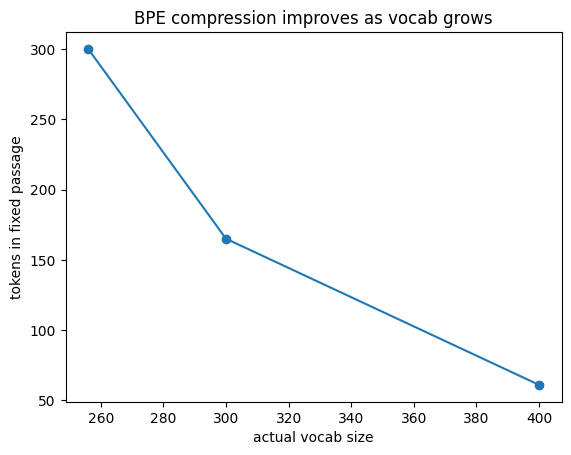

In [24]:
# Use small vocab sizes for the built-in corpus. For a larger corpus, try [256, 1024, 8192].
vocab_sizes = [256, 300, 400]

# Uncomment after implementing train_and_measure.
compression_rows = train_and_measure(corpus, passage, vocab_sizes)
for row in compression_rows:
    printable = {k: v for k, v in row.items() if k != "tokenizer"}
    print(printable)
plt.plot([row["vocab_size_actual"] for row in compression_rows], [row["token_count"] for row in compression_rows], marker="o")
plt.xlabel("actual vocab size")
plt.ylabel("tokens in fixed passage")
plt.title("BPE compression improves as vocab grows")
plt.show()

## Exercise 5 - Inspect Learned Tokens

Print early and late learned vocab entries. Early learned IDs should usually be short, high-frequency byte patterns. Later learned IDs tend to be longer and more corpus-specific.

In [ ]:
"Question: Why should token IDs just above 255 usually represent very common patterns?"
"Answer: Because these are the byte pairs that statistically occur most frequently"

"Question: What kind of learned token would count as corpus-specific rather than generally useful?"
"Answer: A pattern that occurs in the corpus but isn't statistically generalizable outside. Could be something like artifacts in the file format encoding"

In [29]:
def token_bytes_display(token_bytes: bytes) -> str:
    """Display bytes as text when possible, with escapes for non-printing bytes."""
    return token_bytes.decode("utf-8", errors="backslashreplace")


def learned_vocab_window(tok: BPETokenizer, n: int = 20) -> tuple[list[tuple[int, str]], list[tuple[int, str]]]:
    """Return first and last n learned vocab entries as printable pairs."""
    # TODO: collect learned IDs, i.e. IDs >= 256
    # TODO: return first n and last n entries as (id, display_text) tuples
    first_n = []
    last_n = []
    for i in range(n):
        index = i + 256
        decoded = tok.decode([index])
        first_n.append((index, decoded))

        index = len(tok.vocab) - i - 1
        decoded = tok.decode([index])
        last_n.append((index, decoded))

    return (first_n, last_n)

In [30]:
# Uncomment after running the compression experiment.
largest_tok = compression_rows[-1]["tokenizer"]
first_tokens, last_tokens = learned_vocab_window(largest_tok, n=20)
print("First learned tokens:")
for token_id, text in first_tokens:
    print(token_id, repr(text))
print("\nLast learned tokens:")
for token_id, text in last_tokens:
    print(token_id, repr(text))

First learned tokens:
256 ' t'
257 'he'
258 'or'
259 's '
260 ' the'
261 'n '
262 'er'
263 'at'
264 ' s'
265 ' i'
266 're'
267 'en'
268 'co'
269 'us'
270 'wor'
271 'word'
272 'The'
273 'qu'
274 'ver'
275 ' l'

Last learned tokens:
399 'The quick brown fox jumps over the lazy dog. The theater is there,\nand the theory of tokenization is that frequent text fragments become\nshorter symbols. In a small corpus, common words '
398 'The quick brown fox jumps over the lazy dog. The theater is there,\nand the theory of tokenization is that frequent text fragments become\nshorter symbols. In a small corpus, common '
397 'The quick brown fox jumps over the lazy dog. The theater is there,\nand the theory of tokenization is that frequent text fragments become\nshorter symbols. In a small corpus, commo'
396 'The quick brown fox jumps over the lazy dog. The theater is there,\nand the theory of tokenization is that frequent text fragments become\nshorter symbols. In a small corpus, comm'
395 'The qui

In [33]:
"Question: Name two early learned tokens and explain why they are plausible frequent patterns."
"Answer: ' t' and 'he'  These are very common letter pairs in English especiallt with the word 'the' "

"Question: Name one late learned token and explain what makes it more specific."
"Answer: 'The quick brown fox jumps over the lazy dog. The theater is there,\nand the theory of tokenization is that frequent text fragments become\nshorter symbols. In a small corpus, common words '     At this point it's just learning specific phrases from the corpus because there's not enough repeated smaller patterns"

"Answer: 'The quick brown fox jumps over the lazy dog. The theater is there,\nand the theory of tokenization is that frequent text fragments become\nshorter symbols. In a small corpus, common words '     At this point it's just learning specific phrases from the corpus because there's not enough repeated smaller patterns"

## Exercise 6 - Optional Pre-Tokenization

GPT-2-style tokenizers split text before BPE so merges do not freely cross every boundary. This is optional; treat it as an extension after the core tokenizer passes tests.

In [34]:
"Question: Why might merging across whitespace create less useful tokens?"
"Answer: Because words are natural delineation of meaning. In some sense words (which are separated by spaces) are already useful tokenization pattern"

"Question: What would you compare before and after adding pre-tokenization?"
"Answer: I would compare compression on out of sample corpus"

'Answer: I would compare compression on out of sample corpus'

## Submission Notes

When complete, ask a coding agent to grade your Module 04 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.